In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/raw/data.csv")
df.head()
df.sample(5)

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
43434,TransactionId_80371,BatchId_18970,AccountId_3987,SubscriptionId_3274,CustomerId_4437,UGX,256,ProviderId_5,ProductId_3,airtime,ChannelId_3,10000.0,10000,2018-12-28T07:08:06Z,4,0
25573,TransactionId_84173,BatchId_12138,AccountId_3206,SubscriptionId_1372,CustomerId_3634,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-12-13T19:37:29Z,2,0
75424,TransactionId_121169,BatchId_28729,AccountId_19,SubscriptionId_1315,CustomerId_335,UGX,256,ProviderId_6,ProductId_3,airtime,ChannelId_3,1000.0,1000,2019-01-27T19:30:13Z,2,0
30311,TransactionId_1059,BatchId_11615,AccountId_4841,SubscriptionId_3829,CustomerId_2728,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-50.0,50,2018-12-17T07:24:15Z,2,0
92538,TransactionId_105657,BatchId_77323,AccountId_3690,SubscriptionId_3067,CustomerId_4132,UGX,256,ProviderId_5,ProductId_3,airtime,ChannelId_3,2000.0,2000,2019-02-10T12:51:48Z,4,0


Dataset Overview

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 95,662
Columns: 16


In [4]:
df.columns.tolist()

['TransactionId',
 'BatchId',
 'AccountId',
 'SubscriptionId',
 'CustomerId',
 'CurrencyCode',
 'CountryCode',
 'ProviderId',
 'ProductId',
 'ProductCategory',
 'ChannelId',
 'Amount',
 'Value',
 'TransactionStartTime',
 'PricingStrategy',
 'FraudResult']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

### Observations
- Dataset contains transaction-level records.
- Both categorical and numerical variables are present.
- TransactionStartTime is currently stored as an object and will require datetime conversion.


Summary Statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

summary = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "std": df[numeric_cols].std(),
    "skewness": df[numeric_cols].skew()
})

summary

,mean,median,std,skewness
CountryCode,256.000000,256.0,0.000000,0.000000
Amount,6717.846433,1000.0,123306.797164,51.098490
Value,9900.583941,1000.0,123122.087776,51.291086
PricingStrategy,2.255974,2.0,0.732924,1.659057
FraudResult,0.002018,0.0,0.044872,22.196295


### Observations

- Amount and Value exhibit strong positive skewness.
- Large differences between mean and median indicate the presence of outliers.
- FraudResult is highly imbalanced.

Missing Values Analysis

In [8]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


Visualisation

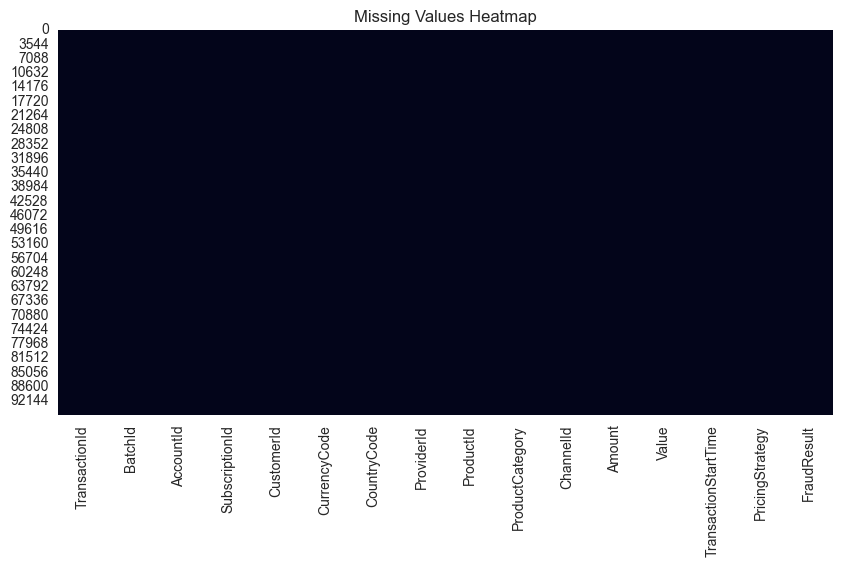

In [9]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### Observations

- No missing values detected.
- Imputation may not be required.

Duplicate Records

In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

df[df.duplicated()].head()

Duplicate Rows: 0


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult


### Observations

- Duplicate transactions should be investigated before modeling.

Numerical Feature Distributions

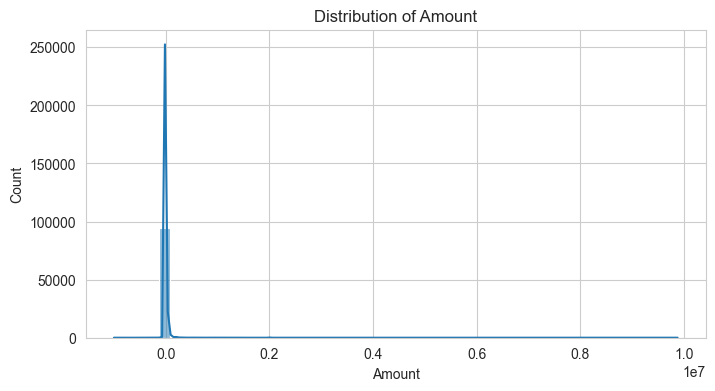

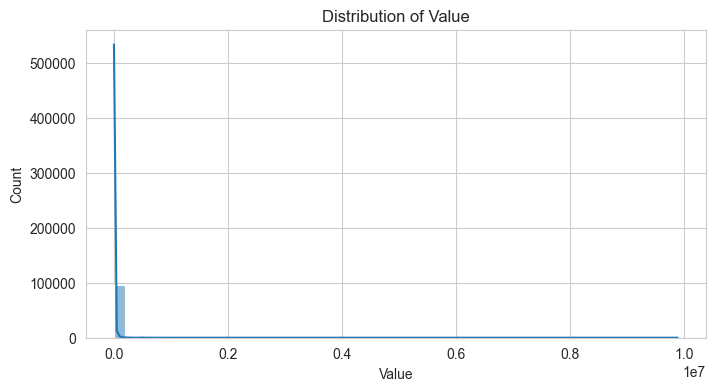

In [11]:
numerical_cols = [
    "Amount",
    "Value"
]

for col in numerical_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        df[col],
        bins=50,
        kde=True
    )
    
    plt.title(f"Distribution of {col}")
    plt.show()

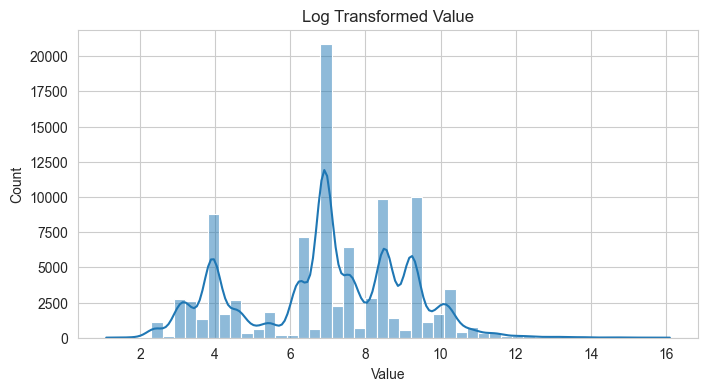

In [12]:
plt.figure(figsize=(8,4))

sns.histplot(
    np.log1p(df["Value"]),
    bins=50,
    kde=True
)

plt.title("Log Transformed Value")
plt.show()

### Observations

- Transaction values are highly right-skewed.
- Log transformation may improve model performance.

Categorical Feature Analysis

In [13]:
categorical_cols = [
    "ProviderId",
    "ProductCategory",
    "ChannelId",
    "PricingStrategy"
]

In [14]:
for col in categorical_cols:
    
    print("\n", col)
    print(df[col].value_counts().head(10))


 ProviderId
ProviderId
ProviderId_4    38189
ProviderId_6    34186
ProviderId_5    14542
ProviderId_1     5643
ProviderId_3     3084
ProviderId_2       18
Name: count, dtype: int64

 ProductCategory
ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

 ChannelId
ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

 PricingStrategy
PricingStrategy
2    79848
4    13562
1     1867
0      385
Name: count, dtype: int64


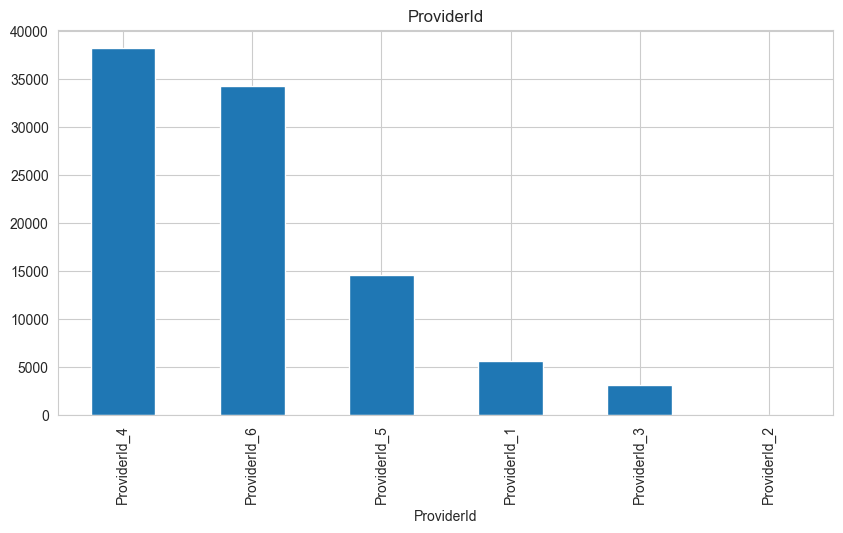

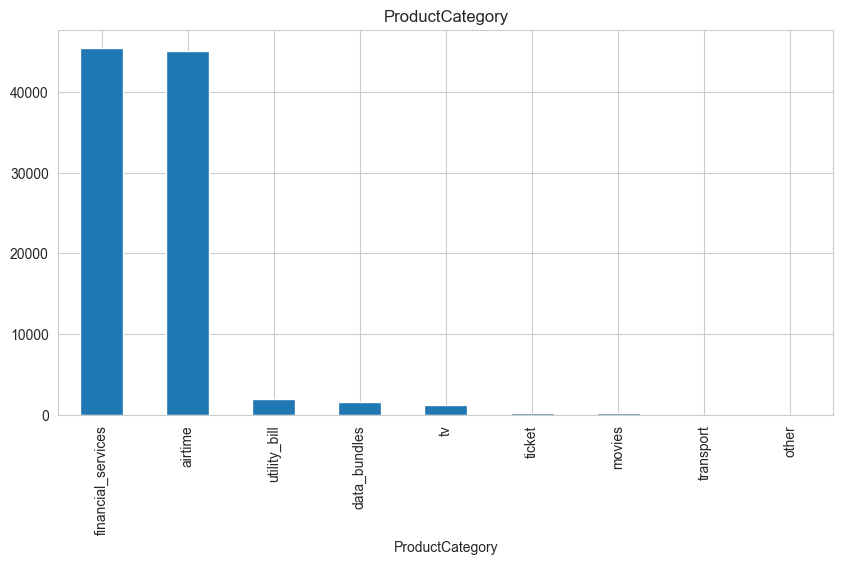

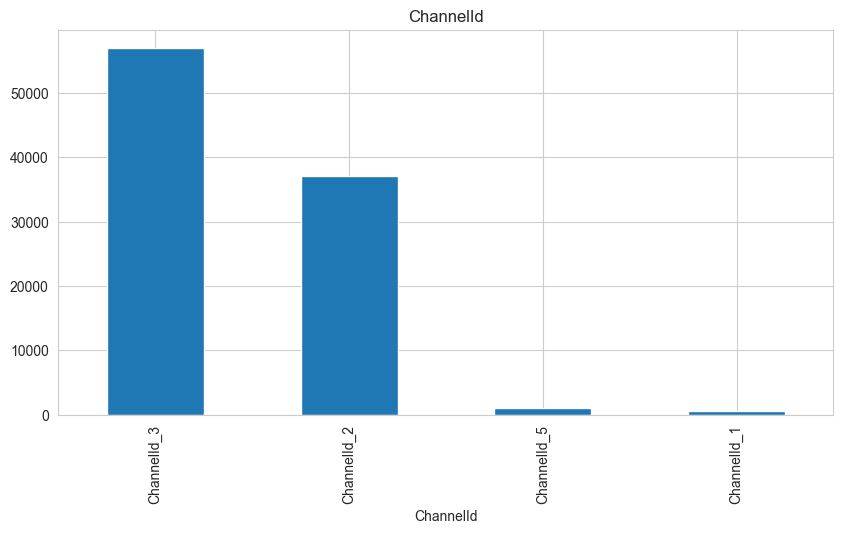

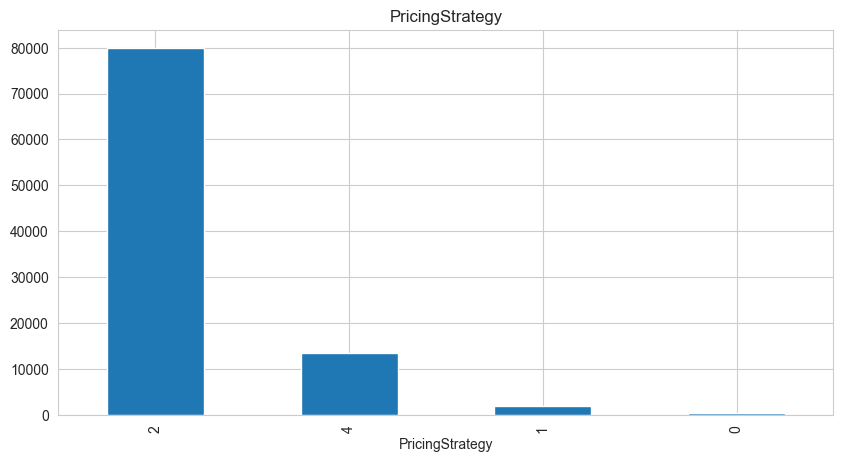

In [15]:
for col in categorical_cols:

    plt.figure(figsize=(10,5))

    df[col].value_counts().head(10).plot(
        kind="bar"
    )

    plt.title(col)

    plt.show()

### Observations

- Transactions are concentrated in a small number of categories.
- Certain channels dominate customer activity.

Time-Based Analysis

In [16]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

In [17]:
df["hour"] = df["TransactionStartTime"].dt.hour

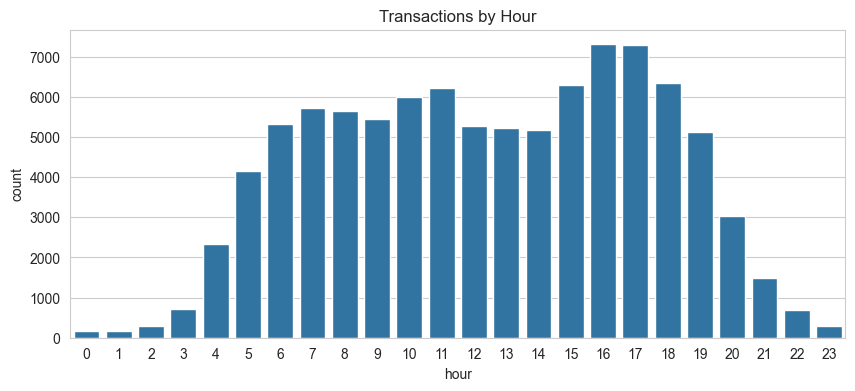

In [18]:
plt.figure(figsize=(10,4))

sns.countplot(
    x="hour",
    data=df
)

plt.title("Transactions by Hour")

plt.show()

In [19]:
df["day_of_week"] = (
    df["TransactionStartTime"]
    .dt.day_name()
)

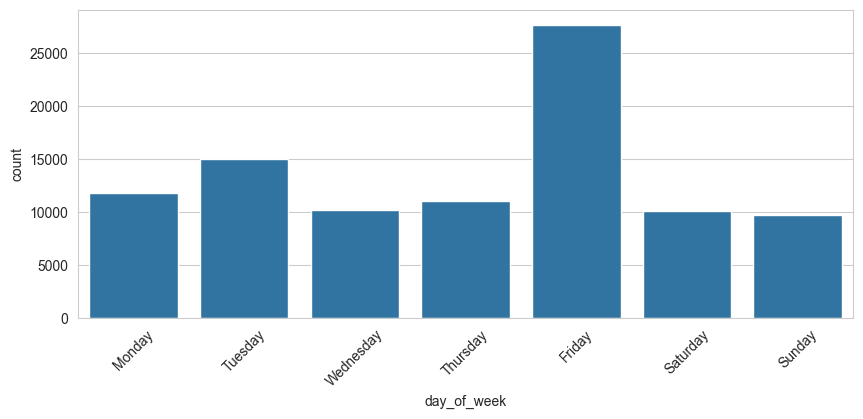

In [20]:
plt.figure(figsize=(10,4))

sns.countplot(
    data=df,
    x="day_of_week",
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]
)

plt.xticks(rotation=45)

plt.show()

### Observations

- Transaction behavior varies by time.
- Temporal variables will likely be useful features.

Correlation Analysis

In [21]:
corr = df.select_dtypes(
    include=np.number
).corr()

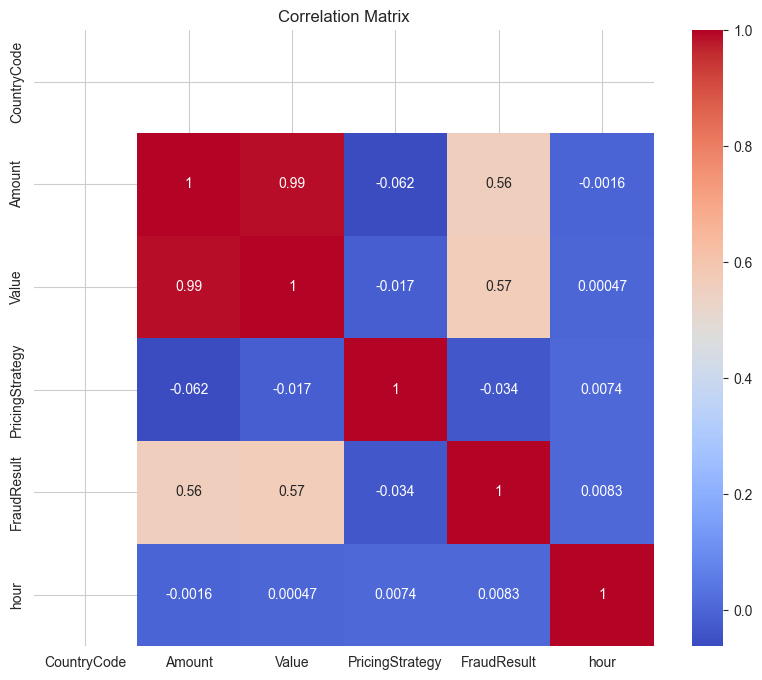

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### Observations

- Amount and Value are strongly correlated.
- Some variables may provide redundant information.

Outlier Detection

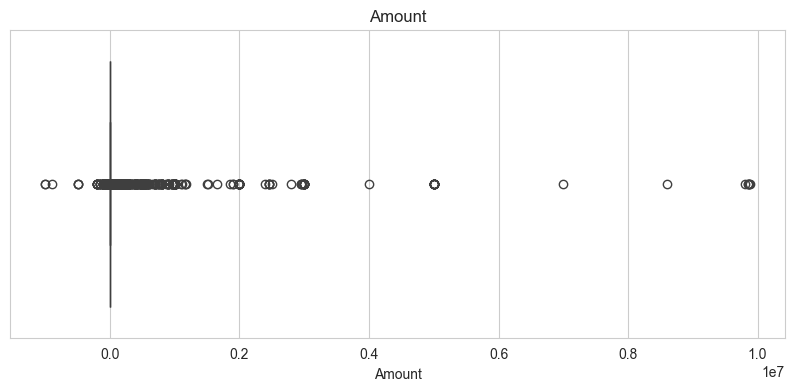

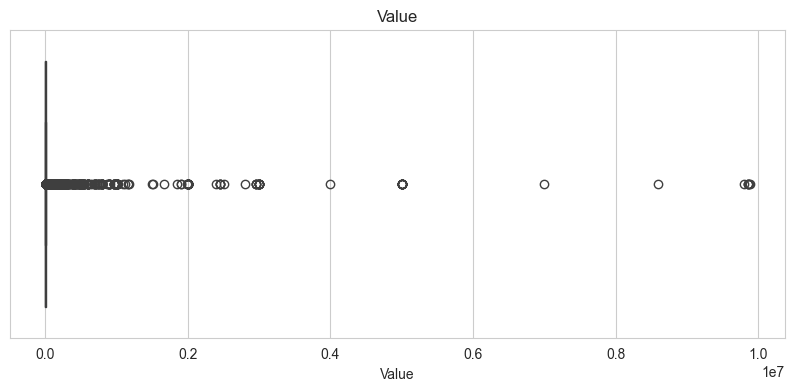

In [23]:
for col in ["Amount", "Value"]:

    plt.figure(figsize=(10,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

In [24]:
for col in ["Amount","Value"]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col)
    print("Outliers:", len(outliers))

Amount
Outliers: 24441
Value
Outliers: 9021


### Observations

- Significant outliers exist in transaction values.
- These likely represent genuine customer behavior and should not be removed blindly.

Fraud Analysis

In [25]:
df["FraudResult"].value_counts()

FraudResult
0    95469
1      193
Name: count, dtype: int64

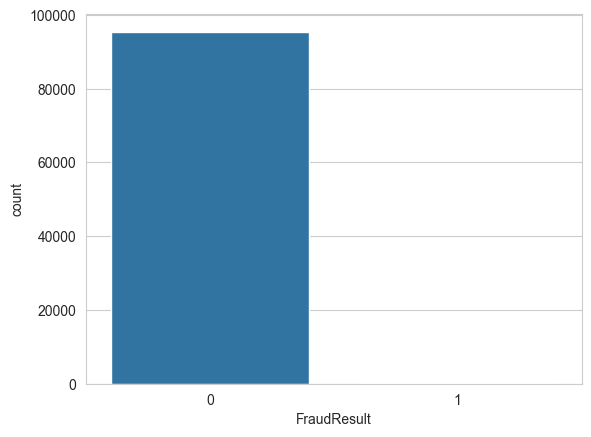

In [26]:
sns.countplot(
    x="FraudResult",
    data=df
)

plt.show()

In [27]:
fraud_rate = (
    df["FraudResult"]
    .mean()
    *100
)

print(
    f"Fraud Rate: {fraud_rate:.2f}%"
)

Fraud Rate: 0.20%


### Observations

- Fraudulent transactions represent a very small fraction of the dataset.
- Future classification tasks will require handling class imbalance.

Business-Oriented Feature Engineering Ideas
## Feature Engineering Opportunities

Potential features for Task 3:

### Aggregate Features
- Total transaction amount per customer
- Average transaction amount
- Transaction count
- Standard deviation of transaction values

### Temporal Features
- Transaction hour
- Transaction day
- Transaction month
- Transaction weekday

### Behavioral Features
- Customer activity frequency
- Spending patterns
- Product diversity
- Channel diversity

### Risk Indicators
- Historical fraud interactions
- Large transaction frequency

# Top Insights

1. The dataset contains over 95,000 transactions and has excellent data quality with no missing values, reducing preprocessing complexity.

2. Transaction Amount and Value are highly skewed with numerous extreme outliers, suggesting that scaling and transformation techniques will be necessary.

3. Customer activity is concentrated within a small number of product categories and transaction channels, indicating strong behavioral patterns that may help predict risk.

4. Transaction timestamps reveal meaningful temporal patterns that can be transformed into predictive features such as hour, day, and month.

5. Fraudulent transactions are extremely rare, highlighting the importance of using appropriate evaluation metrics beyond simple accuracy.